# QF 627 Programming and Computational Finance
## Problem Set `4` | `Questions`

> "Hi Team! 👋

> The current notebook contains 8 questions that help you review our course content.

> Each question asks you to answer with specific results. Some questions are the `reverse-engineering-type` questions as I have asked in exercise problem set 3. Other questions require direct answers (because, given the nature of the question, reverse-engineering is not feasible).

> These questions won’t be difficult to solve—and working through them will strengthen your understanding of the learning materials. This week’s questions ask you to preview the lecture note script for Lesson 4, which we will continue in Lesson 5, and then attempt to answer the exercises.

> This preview exercise will help you consolidate the upcoming lessons more effectively. Once you have completed it, please submit your script via eLearn.

> Enjoy!"

##### First, let's do some quick exercise with stock prices data.

### <font color = green> Activation of necessary libraries. </font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

from plotnine import *
# %pip install --upgrade plotnine mizani pandas_datareader setuptools

> Let's set some print option.

In [2]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

### <font color = red> Question 1</font>. Please import historical stock data from the web on the following financial instruments, and create the following DataFrame that contains adjusted closing prices. 

### Here, the timeframe should be set between the 13th of October 2014 through the 13th of September 2022 (nine years of data).

- `WMT` Stock of Walmart
- `IBM` Stock of IBM

In [3]:
yf.download?

Signature:
yf.download(
    tickers,
    start=None,
    end=None,
    actions=False,
    threads=True,
    ignore_tz=None,
    group_by='column',
    auto_adjust=None,
    back_adjust=False,
    repair=False,
    keepna=False,
    progress=True,
    period=None,
    interval='1d',
    prepost=False,
    proxy=<object object at 0x119e220f0>,
    rounding=False,
    timeout=10,
    session=None,
    multi_level_index=True,
) -> Optional[pandas.core.frame.DataFrame]
Docstring:
Download yahoo tickers
:Parameters:
    tickers : str, list
        List of tickers to download
    period : str
        Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
        Default: 1mo
        Either Use period parameter or use start and end
    interval : str
        Valid intervals: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
        Intraday data cannot extend last 60 days
    start: str
        Download start date string (YYYY-MM-DD) or _datetime, inclusive.
        Default is 99 years ago
        

In [4]:
df =\
(
    yf.download(["WMT", "IBM"], 
        start = dt.datetime(2014, 10, 13), 
        end = dt.datetime(2022, 9, 13), 
        auto_adjust = False)['Adj Close']
)

[*********************100%***********************]  2 of 2 completed


In [5]:
df_ibm = df[['IBM']]
df_wmt = df[['WMT']]

In [6]:
df_ibm, df_wmt

(Ticker             IBM
 Date                  
 2014-10-13  110.969666
 2014-10-14  111.138954
 2014-10-15  109.899399
 2014-10-16  108.744469
 2014-10-17  110.080803
 ...                ...
 2022-09-06  112.858368
 2022-09-07  113.740074
 2022-09-08  114.416931
 2022-09-09  115.058167
 2022-09-12  116.367386
 
 [1993 rows x 1 columns],
 Ticker            WMT
 Date                 
 2014-10-13  20.890917
 2014-10-14  21.004042
 2014-10-15  20.255241
 2014-10-16  19.883535
 2014-10-17  19.958958
 ...               ...
 2022-09-06  42.455509
 2022-09-07  43.546242
 2022-09-08  43.767612
 2022-09-09  43.899143
 2022-09-12  44.293732
 
 [1993 rows x 1 columns])

### <font color = red> Question 2</font>. Please run a simple moving average crossover strategy for `IBM`.

### The two moving windows are 20 and 60 days.

### Please show your positions with a plot.

### <mark> What is shown below is a sample to illustrate the type of visualization you should display; the results you obtain may not necessarily be the same.</mark>

In [7]:
df_ibm['SMA_20'] = df_ibm['IBM'].rolling(window = 20).mean()
df_ibm['SMA_60'] = df_ibm['IBM'].rolling(window = 60).mean()
df_ibm

Ticker,IBM,SMA_20,SMA_60
Date,,,
2014-10-13,110.969666,NaN,NaN
2014-10-14,111.138954,NaN,NaN
2014-10-15,109.899399,NaN,NaN
2014-10-16,108.744469,NaN,NaN
2014-10-17,110.080803,NaN,NaN
...,...,...,...
2022-09-06,112.858368,118.212281,118.906038
2022-09-07,113.740074,118.133907,118.805318
2022-09-08,114.416931,117.998979,118.731710


In [8]:
## Set index to datetime and fill with 0
BUY_or_SELL =\
(
    pd
    .DataFrame(index = df_ibm.index) # investment universe
)
BUY_or_SELL["BUY_or_SELL"] = 0.0
# set the short and long SMA columns
BUY_or_SELL["SMA_20"] =\
(                
    df_ibm['SMA_20']
)
BUY_or_SELL["SMA_60"] =\
(                
    df_ibm['SMA_60']
)
# assign signal
long = 60   # skip NaN values
BUY_or_SELL.loc[BUY_or_SELL.index[long:], "BUY_or_SELL"] =\
( 
    np # if else        # RULE       , True, False
    .where(BUY_or_SELL["SMA_20"][long: ] > BUY_or_SELL["SMA_60"][long: ],
           1.0, -1.0 # team, we are not short-selling when momentum is lost --> pay attention 
           # 1.0 being momentum is activated
           # 0.0 being momentum is lost
           )
)
BUY_or_SELL['BUY_or_SELL'].describe()

count    1993.000000
mean        0.027597
std         0.984693
min        -1.000000
25%        -1.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: BUY_or_SELL, dtype: float64

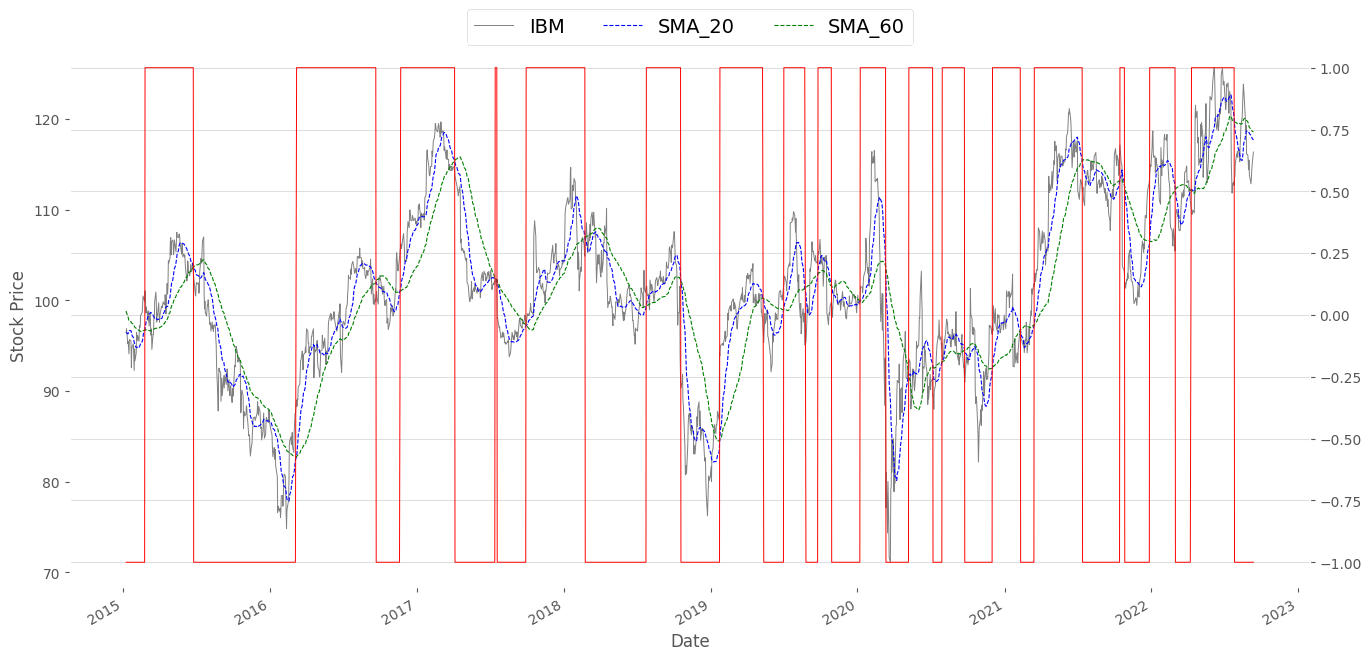

In [9]:
f =\
(
    plt
    .figure(figsize = [16,8]
           )
)

sub=\
(
    f
    .add_subplot(111,
                 ylabel = "Stock Price")
)

# Price Action (Daily)

(
    df_ibm
    ["IBM"][long:]
    .plot(ax = sub,
          lw = 0.70,
          color = "grey")
)

# Moving Averages(Shorter vs. Longer)

(
    BUY_or_SELL.loc[BUY_or_SELL.index[long:]]
    [["SMA_20", "SMA_60"]]
    .plot(ax = sub,
          lw = 0.80,
          style = ["--", "--"],
          color = ["blue", "green"]
         )
)

# Add secondary axis
sub2 = sub.twinx()

# Plot BUY_or_SELL signal
(
    BUY_or_SELL['BUY_or_SELL'].loc[BUY_or_SELL.index[long:]]
    .plot(ax=sub2, 
          lw=0.7, 
          style="-", 
          color="red")
)

# Combine legends and place at top
lines, labels = sub.get_legend_handles_labels()
lines2, labels2 = sub2.get_legend_handles_labels()
sub.grid(False)
sub.legend(lines, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=4)
if sub2.get_legend():
    sub2.get_legend().remove()


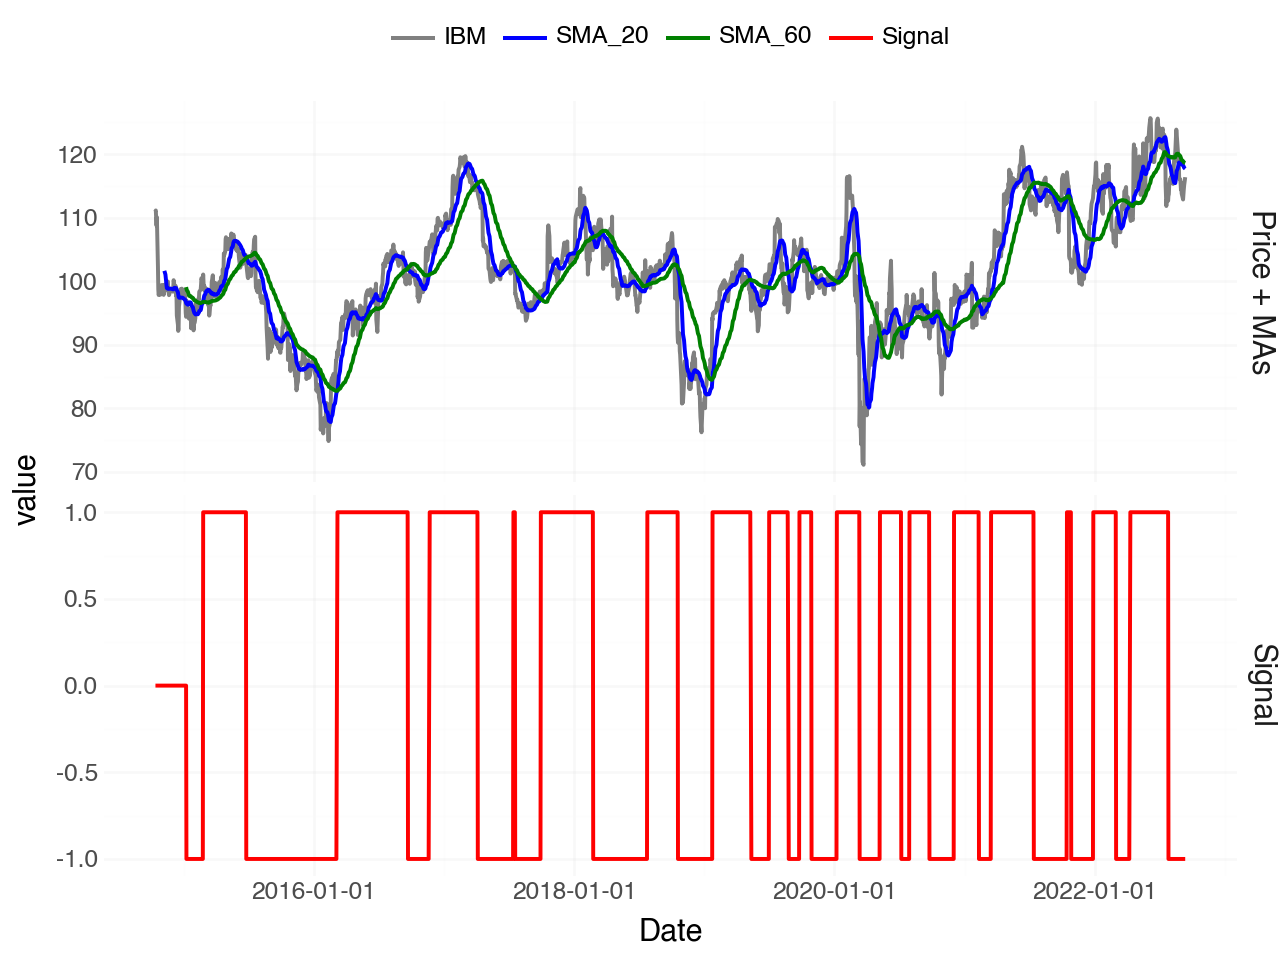

In [10]:
from plotnine import *

# --- Price & MAs ---
df_price = (
    pd.concat([
        df_ibm.assign(Date=df_ibm.index)[['Date','IBM']]
            .rename(columns={'IBM':'value'}).assign(Series='IBM'),
        BUY_or_SELL.assign(Date=BUY_or_SELL.index)[['Date','SMA_20']]
            .rename(columns={'SMA_20':'value'}).assign(Series='SMA_20'),
        BUY_or_SELL.assign(Date=BUY_or_SELL.index)[['Date','SMA_60']]
            .rename(columns={'SMA_60':'value'}).assign(Series='SMA_60')
    ], ignore_index=True)
)
df_price['Panel'] = 'Price + MAs'

# --- Signal ---
df_signal = (
    BUY_or_SELL.assign(Date=BUY_or_SELL.index)[['Date','BUY_or_SELL']]
        .rename(columns={'BUY_or_SELL':'value'})
        .assign(Series='Signal', Panel='Signal')
)

# --- Combine ---
df_all = pd.concat([df_price, df_signal], ignore_index=True)

# --- Plot ---
p = (
    ggplot(df_all, aes(x='Date', y='value', color='Series'))
    + geom_line(size=0.8)
    + facet_grid('Panel ~ .', scales="free_y")
    + scale_color_manual(values={
        "IBM":"grey", "SMA_20":"blue", "SMA_60":"green", "Signal":"red"
    })
    + theme_minimal()
    + theme(
        legend_position="top",
        legend_title=element_blank(),
        strip_text=element_text(size=11, weight="bold")
    )
)

p


### <font color = red> Question 3</font>. Based on your lines of codes that lead to answer 2 above, compare the returns to see if the strategy leads to a win over the passive benchmark investment.

In [11]:
df_ibm = df_ibm.loc[BUY_or_SELL.index[long:]]

<Axes: xlabel='Date'>

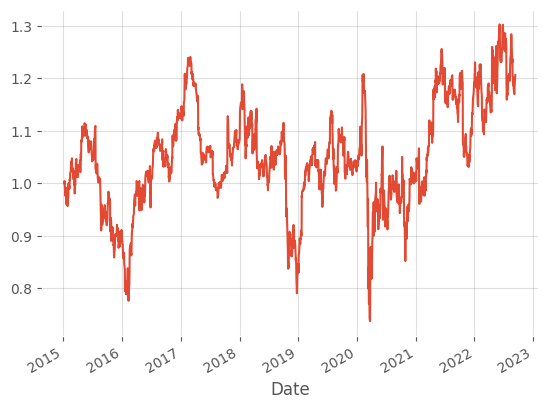

In [12]:
(df_ibm['IBM'].pct_change().fillna(0) + 1).cumprod().plot()

In [13]:
df_ibm['RETURNS'] =\
(
    (df_ibm['IBM'].pct_change().fillna(0) + 1).cumprod()
)

In [14]:
df =\
(    pd.concat([df_ibm, 
           BUY_or_SELL.loc[BUY_or_SELL.index[long:]][['BUY_or_SELL']]],
          axis=1))

In [15]:
df['STRATEGY'] =\
(
    df['IBM'].pct_change().fillna(0) * df['BUY_or_SELL'] + 1
).cumprod()

<Axes: xlabel='Date'>

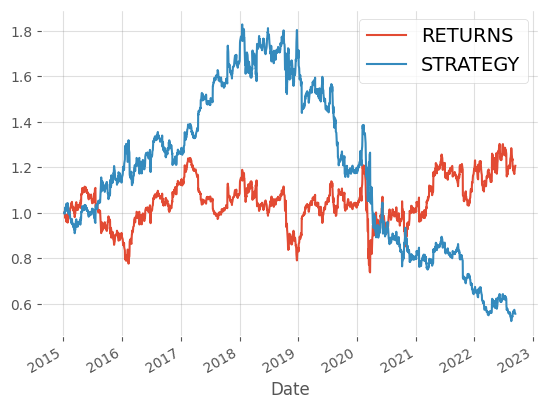

In [16]:
df[['RETURNS', 'STRATEGY']].plot()

### <font color = red> Question 4</font>. Based on your lines of codes that lead to answer 3 above, please calculate the maximum drawdown and the longest drawdown period.

In [17]:
df_ibm.cummax?

Signature:
df_ibm.cummax(
    axis: 'Axis | None' = None,
    skipna: 'bool' = True,
    *args,
    **kwargs,
)
Docstring:
Return cumulative maximum over a DataFrame or Series axis.

Returns a DataFrame or Series of the same size containing the cumulative
maximum.

Parameters
----------
axis : {0 or 'index', 1 or 'columns'}, default 0
    The index or the name of the axis. 0 is equivalent to None or 'index'.
    For `Series` this parameter is unused and defaults to 0.
skipna : bool, default True
    Exclude NA/null values. If an entire row/column is NA, the result
    will be NA.
*args, **kwargs
    Additional keywords have no effect but might be accepted for
    compatibility with NumPy.

Returns
-------
Series or DataFrame
    Return cumulative maximum of Series or DataFrame.

See Also
--------
core.window.expanding.Expanding.max : Similar functionality
    but ignores ``NaN`` values.
DataFrame.max : Return the maximum over
    DataFrame axis.
DataFrame.cummax : Return cumulative max

In [18]:
window = len(df_ibm)

rolling_max =\
(
    df_ibm
    ['IBM']
    .rolling(window = window, 
             min_periods = 1)
    .max()
)

daily_drawdown =\
(
    df_ibm['IBM'] / rolling_max - 1.0
)

daily_drawdown 

Date
2015-01-08    0.000000
2015-01-09    0.000000
2015-01-12   -0.016781
2015-01-13   -0.014455
2015-01-14   -0.020803
                ...   
2022-09-06   -0.101928
2022-09-07   -0.094911
2022-09-08   -0.089525
2022-09-09   -0.084423
2022-09-12   -0.074005
Name: IBM, Length: 1933, dtype: float64

In [19]:
max_daily_drawdown =\
(
    daily_drawdown
    .rolling(window = window, 
             min_periods = 1)
    .min()
)

MAX drawdown of buy-and-hold strategy


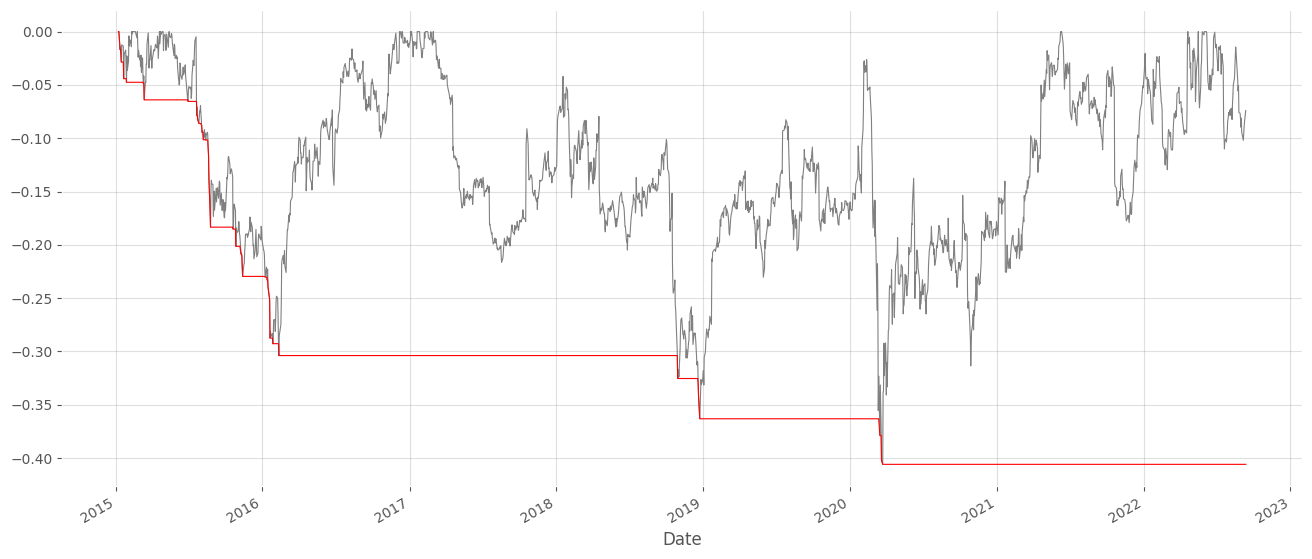

In [20]:
## Max drawdown of long-term buy-and-hold strategy
fig = plt.figure(figsize = [16, 7]
                )

daily_drawdown.plot(color = "grey",
                    lw = 0.80)

max_daily_drawdown.plot(color = "red",
                        lw = 0.80)
print("MAX drawdown of buy-and-hold strategy")
plt.show()

In [21]:
max_daily_drawdown.min(), 

(np.float64(-0.4058520319208231),)

In [22]:
streaks = (max_daily_drawdown != max_daily_drawdown.shift()).cumsum()   # increments when value changes
longest = max_daily_drawdown.groupby(streaks).size().max()

print("Longest streak length:", longest)

Longest streak length: 685


<Axes: xlabel='Date'>

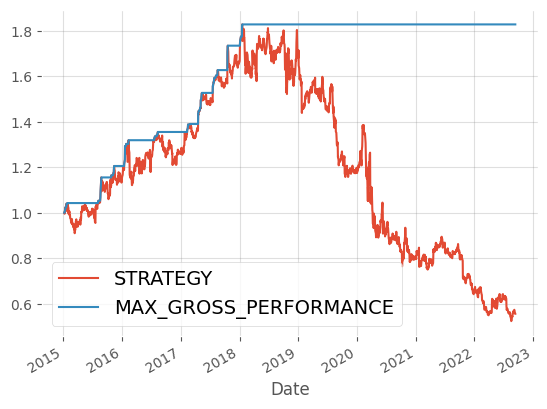

In [23]:
window = len(df_ibm)

rolling_max =\
(
    df
    ['STRATEGY']
    .rolling(window = window, 
             min_periods = 1)
    .max()
)

df['MAX_GROSS_PERFORMANCE'] = rolling_max

df[['STRATEGY', 'MAX_GROSS_PERFORMANCE']].plot()

MAX drawdown of the STRATEGY


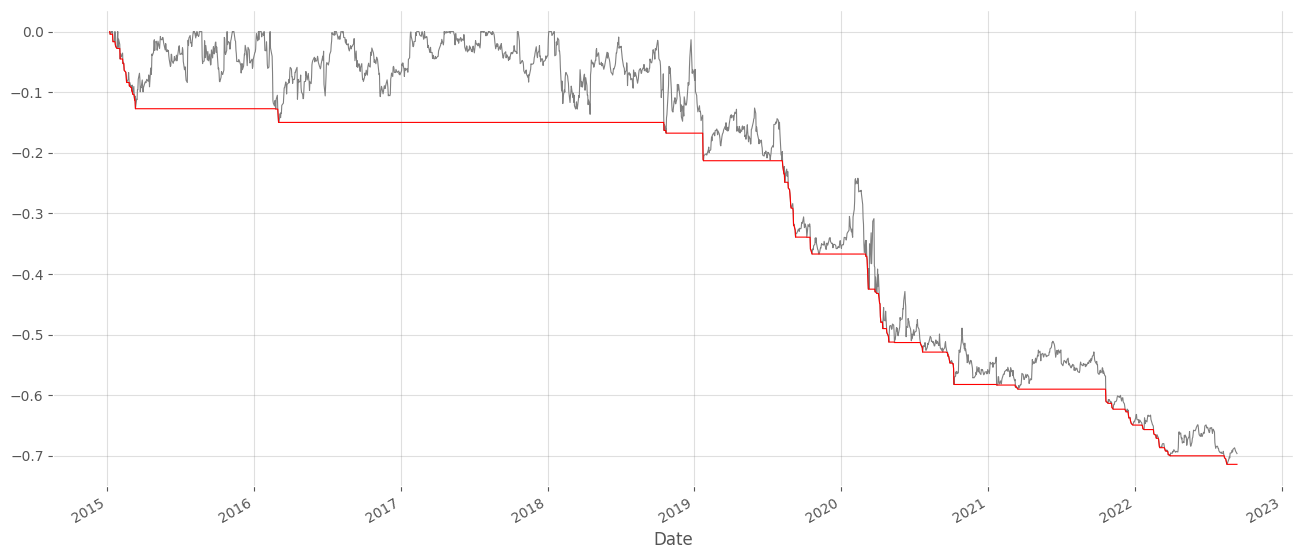

In [24]:
## Max Drawdown of the Strategy
daily_drawdown =\
(
    df['STRATEGY'] / rolling_max - 1.0
)


rolling_max =\
(
    df['STRATEGY']
    .rolling(window = window, 
             min_periods = 1)
    .max()
)

max_daily_drawdown =\
(
    daily_drawdown
    .rolling(window = window, 
             min_periods = 1)
    .min()
)

fig = plt.figure(figsize = [16, 7]
                )

daily_drawdown.plot(color = "grey",
                    lw = 0.80)

max_daily_drawdown.plot(color = "red",
                        lw = 0.80)
print("MAX drawdown of the STRATEGY")
plt.show()

In [25]:
streaks = (rolling_max != rolling_max.shift()).cumsum()   # increments when value changes
longest = rolling_max.groupby(streaks).size().max()

In [26]:

print(f"The maximum drawdown is about {max_daily_drawdown.min()*100:.2f} percentage points.")
print(f"The longest drawdown period lasts for {longest} days.")

The maximum drawdown is about -71.40 percentage points.
The longest drawdown period lasts for 1171 days.


### Please make sure to answer below.

    The maximum drawdown is about ___________ percentage points.
    The longest drawdown period lasts for ___________ days.

In [27]:
df_ibm = df

### <font color = red> Question 5</font>. Now let’s have a look at the stock price of Walmart (WMT). Please run a simple moving average crossover strategy.

### The two moving windows are 50 and 200 days.

### Now, please visualize your buy positions using red dots, and your sell positions using blue dots.

In [28]:
## Set index to datetime and fill with 0
BUY_or_SELL =\
(
    pd
    .DataFrame(index = df_wmt.index) # investment universe
)
BUY_or_SELL["BUY_or_SELL"] = 0.0
# set the short and long SMA columns
BUY_or_SELL["SMA_50"] =\
(
    df_wmt['WMT'].rolling(window = 50).mean()
)
BUY_or_SELL["SMA_200"] =\
(
    df_wmt['WMT'].rolling(window = 200).mean()
)
# assign signal
long = 200   # skip NaN values
BUY_or_SELL.loc[BUY_or_SELL.index[long:], "BUY_or_SELL"] =\
( 
    np # if else        # RULE       , True, False
    .where(BUY_or_SELL["SMA_50"][long: ] > BUY_or_SELL["SMA_200"][long: ],
           1.0, 0.0 # team, we are not short-selling when momentum is lost --> pay attention 
           # 1.0 being momentum is activated
           # 0.0 being momentum is lost
           )
)

BUY_or_SELL['WMT'] = df_wmt['WMT']

BUY_or_SELL['BUY_or_SELL'].describe()

count    1993.000000
mean        0.631209
std         0.482598
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: BUY_or_SELL, dtype: float64

In [29]:
BUY_or_SELL =\
(
    BUY_or_SELL.loc[BUY_or_SELL.index[long:]]
)

In [30]:
BUY_or_SELL["positions"] =\
(
    BUY_or_SELL["BUY_or_SELL"]
    .diff()
)

BUY_or_SELL[['BUY_or_SELL', 'SMA_50', 'SMA_200', 'positions']]

,BUY_or_SELL,SMA_50,SMA_200,positions
Date,,,,
2015-07-30,0.0,20.055918,21.788871,NaN
2015-07-31,0.0,20.034421,21.782536,0.0
2015-08-03,0.0,20.012869,21.780220,0.0
2015-08-04,0.0,19.993071,21.779858,0.0
2015-08-05,0.0,19.988201,21.781535,0.0
...,...,...,...,...
2022-09-06,0.0,41.549547,43.848764,0.0
2022-09-07,0.0,41.627555,43.840473,0.0
2022-09-08,0.0,41.721170,43.834505,0.0


In [31]:
# Keep only rows where positions != 0
df_nonzero = BUY_or_SELL[BUY_or_SELL["positions"] != 0].copy()

# Add previous row values for comparison
df_nonzero["prev_buy_or_sell"] = df_nonzero["BUY_or_SELL"].shift(1)
df_nonzero["prev_positions"] = df_nonzero["positions"].shift(1)

# Example: filter where current differs from previous
df_diff = df_nonzero[df_nonzero["positions"] != df_nonzero["prev_positions"]]


In [32]:
df_diff[['positions', 'BUY_or_SELL', 'prev_positions', 'prev_buy_or_sell']]

,positions,BUY_or_SELL,prev_positions,prev_buy_or_sell
Date,,,,
2015-07-30,NaN,0.0,NaN,NaN
2016-03-14,1.0,1.0,NaN,0.0
2016-12-08,-1.0,0.0,1.0,1.0
2016-12-22,1.0,1.0,-1.0,0.0
2017-01-11,-1.0,0.0,1.0,1.0
2017-04-13,1.0,1.0,-1.0,0.0
2018-04-30,-1.0,0.0,1.0,1.0
2018-09-11,1.0,1.0,-1.0,0.0
2020-03-30,-1.0,0.0,1.0,1.0


In [33]:
BUY_or_SELL['positions'].unique()

array([nan,  0.,  1., -1.])

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_78051/2576260994.py:40: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter


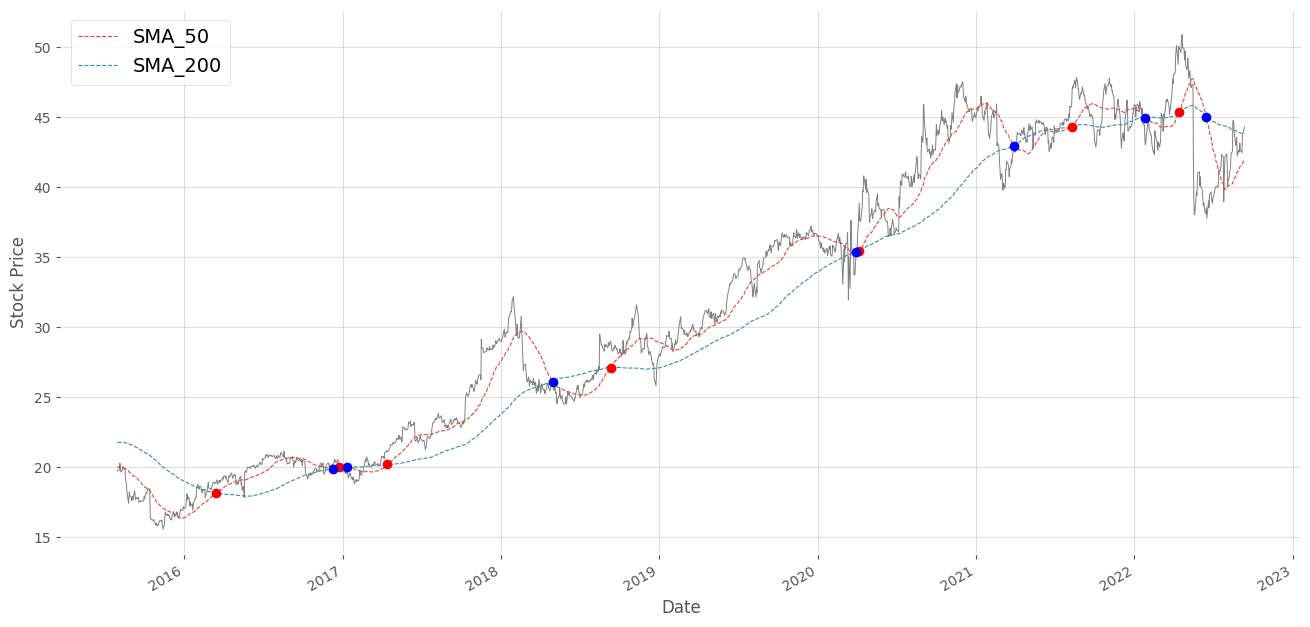

In [34]:
f =\
(
    plt
    .figure(figsize = [16,8]
           )
)

sub=\
(
    f
    .add_subplot(111,
                 ylabel = "Stock Price")
)

# Price Action (Daily)

(
    BUY_or_SELL
    ["WMT"]
    .plot(ax = sub,
          lw = 0.70,
          color = "grey")
)

# Moving Averages(Shorter vs. Longer)

(
    BUY_or_SELL
    [["SMA_50", "SMA_200"]]
    .plot(ax = sub,
          lw = 0.80,
          style = ["--", "--"]
         )
)

# BUY Signal

(
    sub
    .plot(BUY_or_SELL[BUY_or_SELL.positions == 1.0].index,
          BUY_or_SELL.SMA_50[BUY_or_SELL.positions == 1.0],
          ".",
          color = "red",
          markersize = 12)
)

# SELL Signal

(
    sub
    .plot(BUY_or_SELL[BUY_or_SELL.positions == -1.0].index,
          BUY_or_SELL.SMA_50[BUY_or_SELL.positions == -1.0],
          ".",
          color = "blue",
          markersize = 12)
)

In [35]:
df

,IBM,SMA_20,SMA_60,RETURNS,BUY_or_SELL,STRATEGY,MAX_GROSS_PERFORMANCE
Date,,,,,,,
2015-01-08,96.447983,96.481467,98.826419,1.000000,-1.0,1.000000,1.000000
2015-01-09,96.868057,96.438849,98.588571,1.004355,-1.0,0.995645,1.000000
2015-01-12,95.242516,96.297909,98.344290,0.987501,-1.0,1.012352,1.012352
2015-01-13,95.467804,96.341439,98.123012,0.989837,-1.0,1.009958,1.012352
2015-01-14,94.852928,96.424847,97.869214,0.983462,-1.0,1.016463,1.016463
...,...,...,...,...,...,...,...
2022-09-06,112.858368,118.212281,118.906038,1.170148,-1.0,0.572983,1.828652
2022-09-07,113.740074,118.133907,118.805318,1.179289,-1.0,0.568506,1.828652
2022-09-08,114.416931,117.998979,118.731710,1.186307,-1.0,0.565123,1.828652


In [ ]:
# check the shift down 1 for tomorrow earnings
n = 10  # number of rows
start = np.random.randint(0, len(BUY_or_SELL) - n)  # random start
BUY_or_SELL.iloc[start:start + n]

,BUY_or_SELL,SMA_50,SMA_200,WMT,positions
Date,,,,,
2016-11-30,1.0,19.943679,19.846714,20.032831,0.0
2016-12-01,1.0,19.935032,19.857968,20.101088,0.0
2016-12-02,1.0,19.927125,19.868769,20.160816,0.0
2016-12-05,1.0,19.913415,19.876884,19.893452,0.0
2016-12-06,1.0,19.906247,19.884412,20.012909,0.0
2016-12-07,1.0,19.899280,19.892110,20.224903,0.0
2016-12-08,0.0,19.893896,19.898154,20.150421,-1.0
2016-12-09,0.0,19.893051,19.905956,20.075932,0.0
2016-12-12,0.0,19.893410,19.916272,20.531425,0.0


In [ ]:
from lets_plot import *
LetsPlot.setup_html()  # initialize

# Reset index to make the index a column
df = BUY_or_SELL.reset_index()
df.rename(columns={'index': 'Date'}, inplace=True)

# Add signals
df['buy_signal'] = df['positions'] == 1.0
df['sell_signal'] = df['positions'] == -1.0

# Plot
p = (
    ggplot(df, aes(x='Date')) +
    geom_line(aes(y='WMT'), color='grey', size=0.7) +
    geom_line(aes(y='SMA_50'), linetype='dashed', size=0.8) +
    geom_line(aes(y='SMA_200'), linetype='dashed', size=0.8) +
    geom_point(aes(y='SMA_50'), data=df[df['buy_signal']], color='red', size=3) +
    geom_point(aes(y='SMA_50'), data=df[df['sell_signal']], color='blue', size=3) +
    ggtitle("Price Action with Signals") +
    ylab("Stock Price") +
    xlab("Date")
)

p


In [ ]:
BUY_or_SELL[BUY_or_SELL["positions"] != 0.0].dropna()

,BUY_or_SELL,SMA_50,SMA_200,WMT,positions
Date,,,,,
2016-03-14,1.0,18.153358,18.146847,18.891027,1.0
2016-12-08,0.0,19.893897,19.898154,20.150419,-1.0
2016-12-22,1.0,19.991173,19.983790,19.935568,1.0
2017-01-11,0.0,20.024300,20.029929,19.631905,-1.0
2017-04-13,1.0,20.211233,20.183350,21.109497,1.0
2018-04-30,0.0,26.115218,26.185285,26.151373,-1.0
2018-09-11,1.0,27.119846,27.118528,28.916586,1.0
2020-03-30,0.0,35.365723,35.367953,35.513500,-1.0
2020-04-06,1.0,35.474684,35.447570,38.867847,1.0


In [ ]:
position_changes = BUY_or_SELL['positions'][BUY_or_SELL["positions"] != 0.0].dropna().count()

### Then, please come up with an answer for the question below.

    Based on simple moving average crossover strategy, there were _______ trading opportunities found.

In [ ]:
print(f"Based on simple moving average crossover strategy, \n there were {position_changes} trading opportunities found.")

Based on simple moving average crossover strategy, 
 there were 14 trading opportunities found.


### <font color = red> Question 6</font> Please draw the strategy returns as shown below.

### <mark> What is shown below is a sample to illustrate the type of visualization you should display; the results you obtain may not necessarily be the same.</mark>

In [ ]:
BUY_or_SELL

,BUY_or_SELL,SMA_50,SMA_200,WMT,positions
Date,,,,,
2015-07-30,0.0,20.055919,21.788871,19.786493,NaN
2015-07-31,0.0,20.034421,21.782537,19.737131,0.0
2015-08-03,0.0,20.012869,21.780220,19.791969,0.0
2015-08-04,0.0,19.993071,21.779858,19.811161,0.0
2015-08-05,0.0,19.988201,21.781535,20.294304,0.0
...,...,...,...,...,...
2022-09-06,0.0,41.549548,43.848764,42.455509,0.0
2022-09-07,0.0,41.627556,43.840474,43.546246,0.0
2022-09-08,0.0,41.721171,43.834506,43.767612,0.0


In [ ]:
BUY_or_SELL['RETURNS'] =\
(
    BUY_or_SELL['WMT'].pct_change().fillna(0).add(1).cumprod()
)


In [ ]:
BUY_or_SELL['STRATEGY'] =\
(BUY_or_SELL['WMT'].pct_change().fillna(0) * BUY_or_SELL['BUY_or_SELL'] + 1).cumprod()

In [ ]:
BUY_or_SELL

,BUY_or_SELL,SMA_50,SMA_200,WMT,positions,RETURNS,STRATEGY
Date,,,,,,,
2015-07-30,0.0,20.055919,21.788871,19.786493,NaN,1.000000,1.000000
2015-07-31,0.0,20.034421,21.782537,19.737131,0.0,0.997505,1.000000
2015-08-03,0.0,20.012869,21.780220,19.791969,0.0,1.000277,1.000000
2015-08-04,0.0,19.993071,21.779858,19.811161,0.0,1.001247,1.000000
2015-08-05,0.0,19.988201,21.781535,20.294304,0.0,1.025665,1.000000
...,...,...,...,...,...,...,...
2022-09-06,0.0,41.549548,43.848764,42.455509,0.0,2.145681,1.259999
2022-09-07,0.0,41.627556,43.840474,43.546246,0.0,2.200807,1.259999
2022-09-08,0.0,41.721171,43.834506,43.767612,0.0,2.211994,1.259999


<Axes: xlabel='Date'>

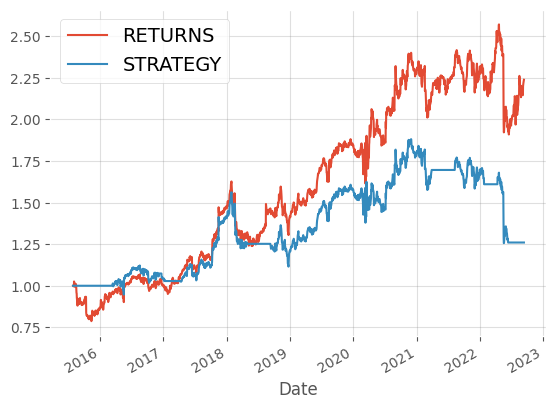

In [ ]:
BUY_or_SELL[['RETURNS', 'STRATEGY']].plot()

In [ ]:
df_wmt = BUY_or_SELL

### <font color = red> Question 7</font>. Please calculate the Sharpe Ratio of the strategies for `IBM` and `WMT`, respectively.

    Simple moving strategy for IBM leads to a Sharpe ratio of _________ . 

    Simple moving strategy for WMT leads to a Sharpe ratio of _________ . 

In [ ]:
df_ibm['strat_daily_return'] = df_ibm['IBM'].pct_change().fillna(0) * df_ibm['BUY_or_SELL']
df_wmt['strat_daily_return'] = df_wmt['WMT'].pct_change().fillna(0) * df_wmt['BUY_or_SELL']

In [ ]:
df_wmt

,BUY_or_SELL,SMA_50,SMA_200,WMT,positions,RETURNS,STRATEGY,strat_daily_return
Date,,,,,,,,
2015-07-30,0.0,20.055919,21.788871,19.786493,NaN,1.000000,1.000000,0.0
2015-07-31,0.0,20.034421,21.782537,19.737131,0.0,0.997505,1.000000,-0.0
2015-08-03,0.0,20.012869,21.780220,19.791969,0.0,1.000277,1.000000,0.0
2015-08-04,0.0,19.993071,21.779858,19.811161,0.0,1.001247,1.000000,0.0
2015-08-05,0.0,19.988201,21.781535,20.294304,0.0,1.025665,1.000000,0.0
...,...,...,...,...,...,...,...,...
2022-09-06,0.0,41.549548,43.848764,42.455509,0.0,2.145681,1.259999,-0.0
2022-09-07,0.0,41.627556,43.840474,43.546246,0.0,2.200807,1.259999,0.0
2022-09-08,0.0,41.721171,43.834506,43.767612,0.0,2.211994,1.259999,0.0


In [ ]:
Sharpe_ibm = (df_ibm['strat_daily_return']).mean() / df_ibm['strat_daily_return'].std() * np.sqrt(252)
Sharpe_wmt = (df_wmt['strat_daily_return']).mean() / df_wmt['strat_daily_return'].std() * np.sqrt(252)
print(f"Simple moving strategy for IBM leads to a Sharpe ratio of {Sharpe_ibm:.2f} .")
print(f"Simple moving strategy for WMT leads to a Sharpe ratio of {Sharpe_wmt:.2f} .")

Simple moving strategy for IBM leads to a Sharpe ratio of -0.19 .
Simple moving strategy for WMT leads to a Sharpe ratio of 0.27 .


### <font color = red> Question 8</font>. Please calculate the Compound Annual Growth Rate (CAGR) of the strategies for `IBM` and `WMT`, respectively.

    Simple moving strategy for IBM leads to a CAGR of _________ .

    Simple moving strategy for WMT leads to a CAGR of _________ .


In [ ]:
days =\
(
    (df_ibm.index[-1] - df_ibm.index[0]).days
)

days

2804

In [ ]:
CAGR_ibm =\
(
    (df_ibm['STRATEGY'].iloc[-1] / df_ibm['STRATEGY'].iloc[0]) ** (365.0 / days) - 1.0
)

CAGR_wmt =\
(
    (df_wmt['STRATEGY'].iloc[-1] / df_wmt['STRATEGY'].iloc[0]) ** (365.0 / days) - 1.0
)


In [ ]:
print(f"Simple moving strategy for IBM leads to a CAGR of {CAGR_ibm * 100:.2f}% .")
print(f"Simple moving strategy for WMT leads to a CAGR of {CAGR_wmt * 100:.2f}% .")

Simple moving strategy for IBM leads to a CAGR of -7.37% .
Simple moving strategy for WMT leads to a CAGR of 3.05% .


### <font color="green">"Thank you for putting your efforts into the exercise problem sets 💯"</font>